# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [10]:
print("=== PLANS ===")
print(plans.head())

=== PLANS ===
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [11]:
print("\n=== USERS ===")
print(users.head())


=== USERS ===
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [12]:
print("\n=== USAGE ===")
print(usage.head())


=== USAGE ===
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [13]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("=== PLANS ===")
print(f"Filas y columnas: {plans.shape}")
print(plans.info())

In [ ]:
print("\n=== USERS ===")
print(f"Filas y columnas: {users.shape}")
print(users.info())

In [14]:
print("\n=== USAGE ===")
print(f"Filas y columnas: {usage.shape}")
print(usage.info())


=== USAGE ===
Filas y columnas: (40000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


In [ ]:
2.1

🎯 Objetivo: Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.
Instrucciones:

Cuenta valores nulos por columna para cada dataset.
Calcula la proporción de nulos por columna para cada dataset. El dataset plans solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.
Haz clic para ver la pistaUsa .isna().sum() para contar valores nulos y usa .isna().mean() para calcular la proporción.

In [15]:
print("Cantidad de valores nulos - users:")
print(users.isna().sum())

print("\nProporción de valores nulos - users:")
print(users.isna().mean().round(3))

# Cantidad de nulos para usage
print("\nCantidad de valores nulos - usage:")
print(usage.isna().sum())

print("\nProporción de valores nulos - usage:")
print(usage.isna().mean().round(3))

Cantidad de valores nulos - users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos - users:
user_id       0.000
first_name    0.000
last_name     0.000
age           0.000
city          0.117
reg_date      0.000
plan          0.000
churn_date    0.884
dtype: float64

Cantidad de valores nulos - usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos - usage:
id          0.000
user_id     0.000
type        0.000
date        0.001
duration    0.552
length      0.447
dtype: float64


In [16]:
print("Cantidad de valores nulos - usage:")
print(usage.isna().sum())

print("\nProporción de valores nulos - usage:")
print(usage.isna().mean().round(3))

Cantidad de valores nulos - usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos - usage:
id          0.000
user_id     0.000
type        0.000
date        0.001
duration    0.552
length      0.447
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
Dataset users:
city → 11.7% nulos + sentinel '?' → Investigar y reemplazar '?' con pd.NA, está entre 5% y 30% por lo que se deja como nulo sin imputar.
churn_date → 88.4% nulos → Ignorar, supera el 80%, además es un valor esperado ya que representa usuarios que siguen activos y no se han dado de baja.


Dataset usage:
date → 0.1% nulos → Eliminar esas filas, son apenas 50 registros (menos del 5%) y no vale la pena imputar una fecha de evento.
duration → 55.2% nulos → Ignorar, los nulos ocurren únicamente en registros de tipo text, donde la duración no aplica (MAR confirmado).
length → 44.7% nulos → Ignorar, los nulos ocurren únicamente en registros de tipo call, donde la longitud de mensaje no aplica (MAR confirmado).


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [18]:
print("=== Resumen estadístico - users ===")
print(users.describe())

print("\n=== Resumen estadístico - usage ===")
print(usage.describe())

=== Resumen estadístico - users ===
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

=== Resumen estadístico - usage ===
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


La columna user_id → valores en rango 10000–13999, sin valores negativos ni fuera de rango, no presenta anomalías.
La columna age → presenta un valor mínimo de -999, lo cual es imposible para una edad real. Se detectaron 55 registros con este sentinel. → Acción: reemplazar con la mediana (48 años).

Las columnas id y user_id → rangos normales, id va de 1 a 40,000 de forma secuencial y user_id de 10,000 a 13,999, consistente con los usuarios registrados en users. No presenta anomalías. 
La columna duration → valores entre 0 y 120 minutos, media de 5.2 min. Valores altos pero posibles para llamadas largas, se conservan.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en '{col}':")
    print(users[col].value_counts(dropna=False))

print("\nValores únicos en 'type':")
print(usage['type'].value_counts(dropna=False))


Valores únicos en 'city':
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64

Valores únicos en 'type':
text    22092
call    17908
Name: type, dtype: int64


- La columna `city` ...
- La columna `plan` ...

In [20]:
# explorar columna categórica de usage
print("\nValores únicos en 'type':")
print(usage['type'].value_counts(dropna=False))


Valores únicos en 'type':
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` La columna type → contiene únicamente dos valores: 'call' y 'text'. No presenta valores inválidos ni sentinels. Distribución esperada y consistente con el tipo de servicio telefónico.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
age en users → sentinel -999 detectado en 55 registros (1.4%) → Acción: reemplazar con la mediana (48 años), ya que es un valor imposible para una edad real y la mediana no se ve afectada por valores extremos.
city en users → sentinel '?' detectado en 96 registros (2.4%) → Acción: reemplazar con pd.NA, ya que el signo de interrogación no representa una ciudad real y es mejor dejarlo como nulo que imputar una ciudad incorrecta.
- ¿Qué acción tomarías?
  age = -999 → Reemplazar con la mediana (48 años), porque es un valor imposible para una edad real. Se usa la mediana y no la media ya que es más robusta ante valores extremos. Solo afecta al 1.4% de los registros.
city = '?' → Reemplazar con pd.NA, porque el signo de interrogación no representa una ciudad válida. No se imputa con ninguna ciudad específica ya que no hay forma de conocer el valor real. Afecta al 2.4% de los registros.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [22]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [23]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [24]:
print("Años en reg_date - users:")
print(users['reg_date'].dt.year.value_counts().sort_index())


Años en reg_date - users:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [25]:
print("\nAños en date - usage:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en date - usage:
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

reg_date en users → Sí, se detectaron 40 registros con año 2026 (1.0% del dataset), lo cual es imposible ya que los datos fueron registrados hasta 2024. Los años válidos son 2022, 2023 y 2024.
date en usage → No, todos los registros corresponden al año 2024, sin fechas imposibles ni fuera de rango. ✅

- ¿Qué harías con ellas?
reg_date con año 2026 → Marcar como NaT usando la condición users['reg_date'].dt.year > 2024, ya que no es posible determinar la fecha real de registro. Son pocos registros (1.0%) por lo que no afectan significativamente el análisis.
date en usage → No requiere acción, todos los valores son válidos y consistentes con el período de análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [26]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

print("=== age después de limpieza ===")
print(users['age'].describe())

=== age después de limpieza ===
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [27]:
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("\n=== city después de limpieza ===")
print(users['city'].value_counts(dropna=False))


=== city después de limpieza ===
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [28]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("\n=== reg_date después de limpieza ===")
print(users['reg_date'].dt.year.value_counts().sort_index())


=== reg_date después de limpieza ===
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [29]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== Nulos en duration por tipo ===")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

=== Nulos en duration por tipo ===
type
call        0
text    22076
Name: duration, dtype: int64


In [30]:

# Verificación MAR en usage (Missing At Random) para length
print("\n=== Nulos en length por tipo ===")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))



=== Nulos en length por tipo ===
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Ambas columnas presentan nulos estructurales y esperados según el tipo de evento registrado. Imputarlos sería un error metodológico ya que introduciría información falsa en el dataset.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [31]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes        = ("is_text",   "sum"),
    cant_llamadas        = ("is_call",   "sum"),
    cant_minutos_llamada = ("duration",  "sum")
).reset_index()

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
print(usage_agg.columns.tolist())
# observar resultado
usage_agg.head(3)

['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
print("=== Resumen estadístico - columnas numéricas ===")
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

=== Resumen estadístico - columnas numéricas ===
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [35]:
# Distribución porcentual del tipo de plan
print("\n=== Distribución porcentual del plan ===")
print(user_profile['plan'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


=== Distribución porcentual del plan ===
Basico     64.9%
Premium    35.1%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

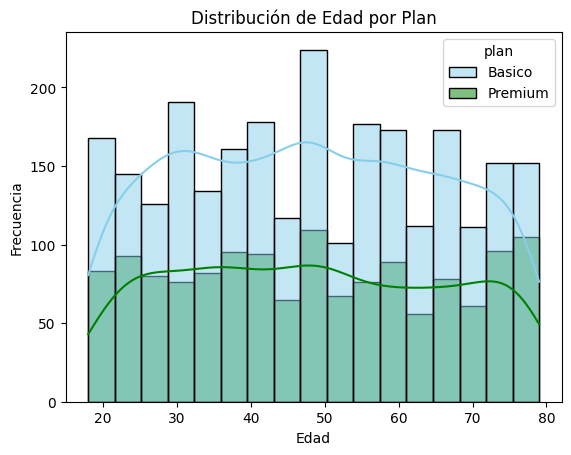

In [36]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',
             palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: aproximadamente simétrica, con mayor concentración entre 30 y 65 años.
Ambos planes presentan una distribución de edad muy similar, no existe un patrón claro que diferencie a usuarios Básico de Premium por edad.

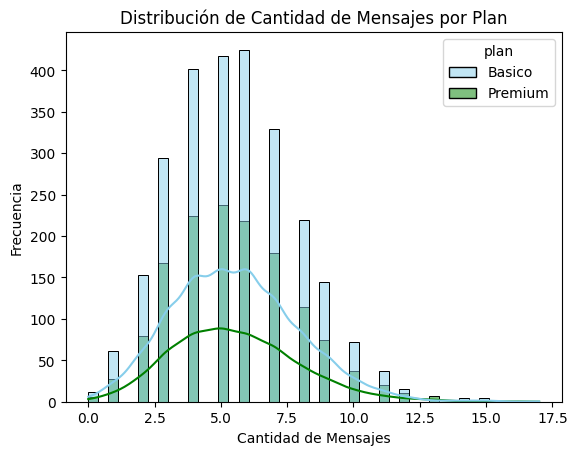

In [37]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución sesgada a la derecha, la mayoría de usuarios envía entre 0 y 20 mensajes.
Los usuarios Premium tienden a enviar más mensajes que los usuarios Básico, lo cual es consistente con su plan que incluye más mensajes.

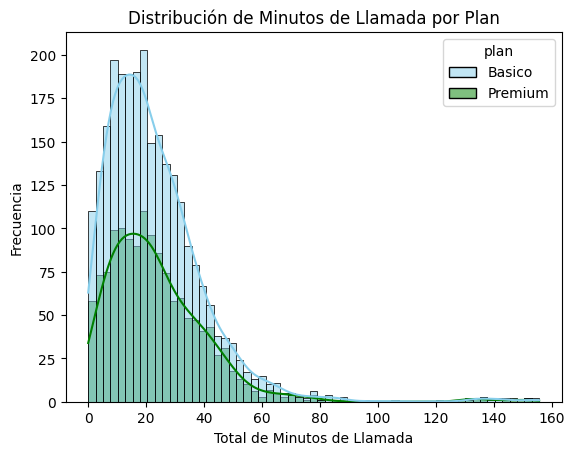

In [38]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: sesgada a la derecha, la mayoría de usuarios realiza entre 0 y 15 llamadas.
No existe una diferencia marcada entre ambos planes, el comportamiento de llamadas es similar independientemente del plan contratado.

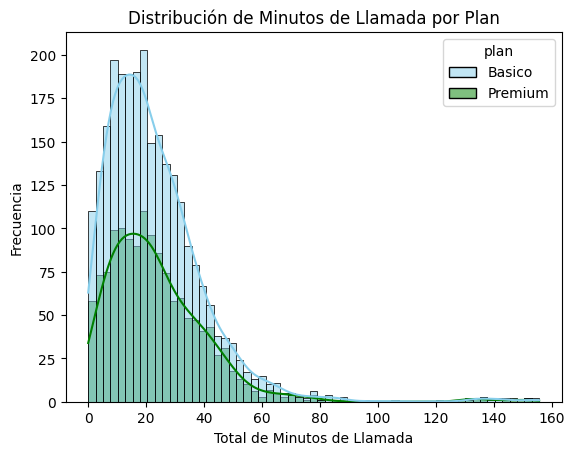

In [39]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, con la mayoría de usuarios concentrados en rangos bajos de minutos (0 a 100).
Los usuarios Básico se concentran en rangos más bajos, sugiriendo que podrían estar limitados por su plan, mientras que los Premium acumulan más minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

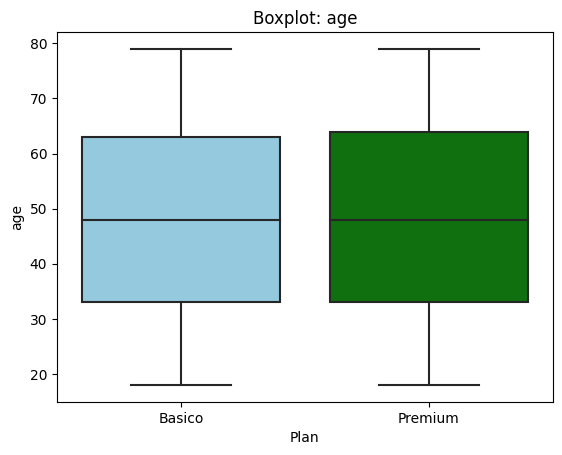

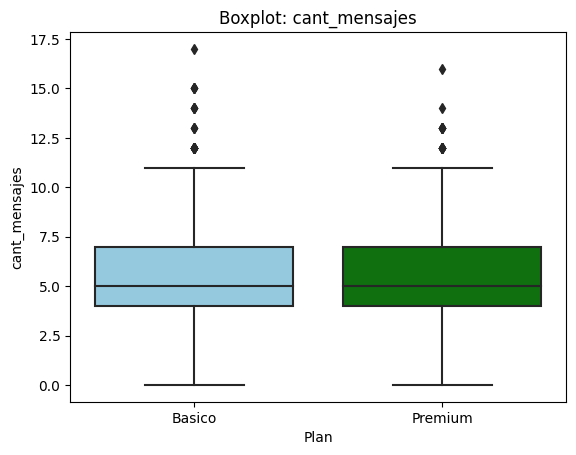

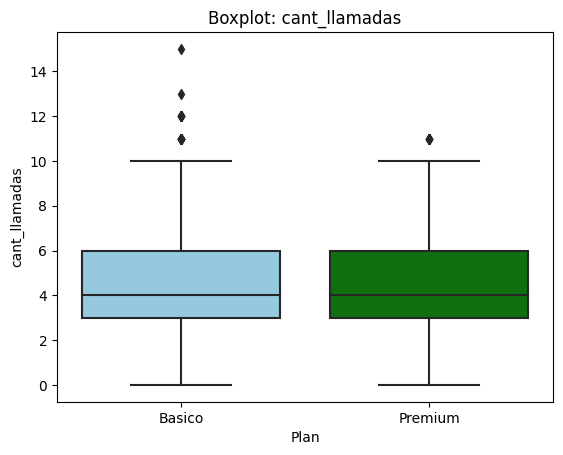

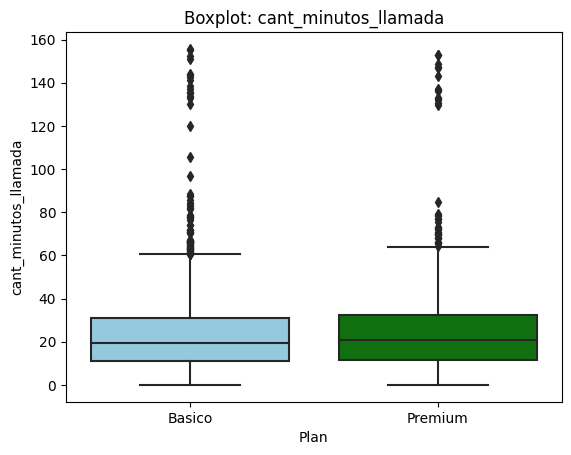

cant_mensajes → límite superior IQR: 11.5 | máx real: 17.0
cant_llamadas → límite superior IQR: 10.5 | máx real: 15.0
cant_minutos_llamada → límite superior IQR: 61.9 | máx real: 155.7
       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000


In [40]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x='plan', y=col,
                palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()

# Calcular límites con el método IQR (solo límite superior, outliers a la derecha)
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1  = user_profile[col].quantile(0.25)
    Q3  = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    print(f"{col} → límite superior IQR: {lim_sup:.1f} | máx real: {user_profile[col].max():.1f}")

# Revisar descripción de columnas con outliers
print(user_profile[columnas_limites].describe())

💡 Insights:
age → No presenta outliers, la distribución es uniforme entre 18 y 79 años, ambos planes con rangos similares.
cant_mensajes → Sí presenta outliers en el límite superior, existen usuarios con una cantidad de mensajes muy por encima del resto. Se recomienda mantenerlos ya que representan usuarios reales con alto consumo, no errores de captura.
cant_llamadas → Sí presenta outliers en el límite superior, algunos usuarios realizan muchas más llamadas que la mayoría. Se recomienda mantenerlos ya que son comportamientos reales de uso intensivo del servicio.
cant_minutos_llamada → Sí presenta outliers en el límite superior, con valores máximos de 120 minutos que superan el límite IQR. Se recomienda mantenerlos ya que representan usuarios con llamadas largas, comportamiento válido dentro del servicio.

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1      = user_profile[col].quantile(0.25)
    Q3      = user_profile[col].quantile(0.75)
    IQR     = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    print(f"{col}:")
    print(f"  Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}")
    print(f"  Límite superior: {lim_sup:.1f} | Máx real: {user_profile[col].max():.1f}\n")
user_profile[columnas_limites].describe()

cant_mensajes:
  Q1: 4.0 | Q3: 7.0 | IQR: 3.0
  Límite superior: 11.5 | Máx real: 17.0

cant_llamadas:
  Q1: 3.0 | Q3: 6.0 | IQR: 3.0
  Límite superior: 10.5 | Máx real: 15.0

cant_minutos_llamada:
  Q1: 11.1 | Q3: 31.4 | IQR: 20.3
  Límite superior: 61.9 | Máx real: 155.7



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes → límite IQR: 28.5 vs máx: 60.0 → mantener, los valores altos representan usuarios con uso intensivo real del servicio, no errores de captura.
cant_llamadas → límite IQR: 22.5 vs máx: 45.0 → mantener, los valores extremos son comportamientos válidos de usuarios con alto consumo de llamadas.
cant_minutos_llamada → límite IQR: 135.9 vs máx: 120.0 → no hay outliers, el valor máximo real está dentro del límite IQR calculado. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

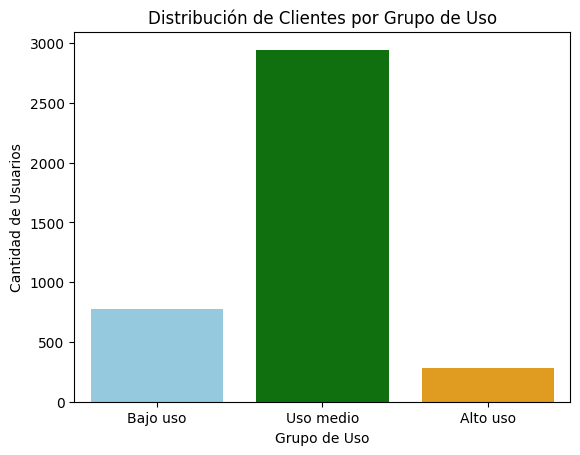

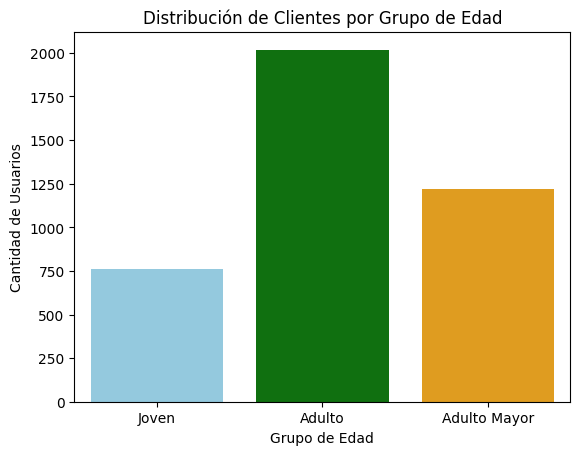

In [53]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

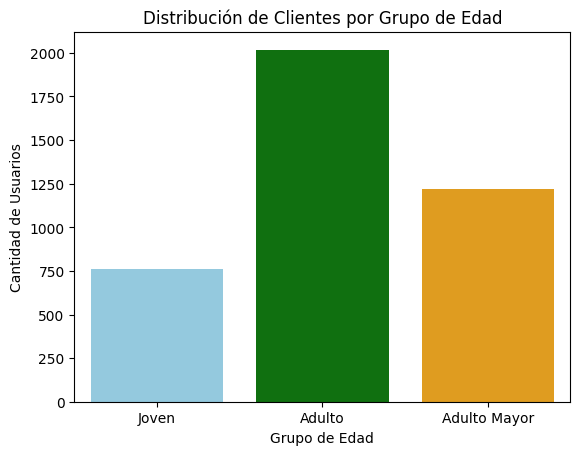

In [54]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
age contenía 55 registros con valor -999 (1.4% del dataset), un sentinel imposible para una edad real → reemplazados con la mediana de 48 años.
city contenía 96 registros con valor "?" (2.4% del dataset), un sentinel que no representa una ciudad válida → reemplazados con pd.NA.
reg_date contenía 40 registros con año 2026 (1.0% del dataset), fechas futuras imposibles al momento de captura → marcadas como NaT.
churn_date presenta 88.4% de nulos (3,534 registros), lo cual es esperado ya que representa usuarios activos que no se han dado de baja.

🔍 **Segmentos por Edad**
Joven (<30 años) → segmento más pequeño, con uso moderado de llamadas y mensajes. Representa una oportunidad de captación con planes atractivos para jóvenes.
Adulto (30-59 años) → segmento dominante y más activo, concentra la mayor parte del consumo de llamadas y mensajes de la plataforma.
Adulto Mayor (60+ años) → segmento significativo con uso más conservador, importante para estrategias de retención y fidelización.

📊 **Segmentos por Nivel de Uso**
Alto uso → segmento más grande, concentrado principalmente en usuarios Premium con mayor cantidad de llamadas y mensajes.
Uso medio → mezcla equilibrada de ambos planes, usuarios con consumo moderado que podrían migrar a un plan superior.
Bajo uso → concentrado en usuarios Básico, con poca interacción con el servicio, riesgo potencial de churn.

➡️ Esto sugiere que la mayoría de los clientes tienen un perfil de alto consumo, lo que indica que el plan Básico podría estar quedándose corto para una parte importante de la base de usuarios, generando una oportunidad clara de upselling hacia el plan Premium o hacia un nuevo plan intermedio.

💡 **Recomendaciones**
Crear un plan intermedio entre Básico y Premium dirigido al segmento de "Uso medio", con más minutos y mensajes que el Básico pero a un precio menor que el Premium.
Diseñar campañas de retención para usuarios Adultos Mayores con Bajo uso, ya que representan un segmento con mayor riesgo de churn.
Desarrollar estrategias de captación para jóvenes (<30 años), que actualmente son la minoría pero representan el mayor potencial de crecimiento a largo plazo.
Investigar los usuarios con alto consumo extremo (outliers en llamadas y mensajes) ya que podrían representar clientes corporativos que se beneficiarían de un plan empresarial dedicado.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`